This cell initializes the TensorFlow environment, verifies GPU availability (Tesla T4), and enables dynamic GPU memory allocation to prevent memory overflow during training.

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision, Recall
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!nvidia-smi

Sun Mar  1 19:13:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled


The HAM10000 dataset was stored in Google Drive and extracted into the Colab runtime environment. File integrity was verified by sampling image paths and checking existence.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!apt-get update -qq && apt-get install -y -qq unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
!mkdir -p /content/HAM10000
!unrar x "/content/drive/MyDrive/HAM10000.rar" "/content/HAM10000/"


Streaming output truncated to the last 5000 lines.
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029323.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029324.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029325.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029326.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029327.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029328.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029329.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029330.jpg      49%  OK 
Extracting  /content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0029331.jpg      49%  OK 
Extr

In [7]:
!ls "/content/HAM10000/archive (2)/HAM10000_images_part_1" | head


ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg
ISIC_0024311.jpg
ISIC_0024312.jpg
ISIC_0024313.jpg
ISIC_0024314.jpg
ISIC_0024315.jpg


Predefined 70/15/15 stratified splits were loaded. The training set exhibits class imbalance (~80% benign, ~20% malignant).

In [8]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/test.csv")

train_df.head()


,image_path,label
0,/content/HAM10000/archive (2)/HAM10000_images_...,0
1,/content/HAM10000/archive (2)/HAM10000_images_...,0
2,/content/HAM10000/archive (2)/HAM10000_images_...,1
3,/content/HAM10000/archive (2)/HAM10000_images_...,0
4,/content/HAM10000/archive (2)/HAM10000_images_...,0


In [9]:
import os

for p in train_df["image_path"].sample(5):
    print(p, os.path.exists(p))

/content/HAM10000/archive (2)/HAM10000_images_part_1/ISIC_0027889.jpg True
/content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0034031.jpg True
/content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0033980.jpg True
/content/HAM10000/archive (2)/HAM10000_images_part_2/ISIC_0031523.jpg True
/content/HAM10000/archive (2)/HAM10000_images_part_1/ISIC_0028807.jpg True


In [10]:
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nLabel distribution (train):")
print(train_df["label"].value_counts(normalize=True))

Train size: 7010
Val size: 1502
Test size: 1503

Label distribution (train):
label
0    0.80485
1    0.19515
Name: proportion, dtype: float64


All images were resized to 224×224 pixels. Batch size was set to 32. TensorFlow AUTOTUNE was used for efficient data pipeline optimization.

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


Images were loaded from disk, decoded as RGB, resized to 224×224, and converted to float32 format before normalization within the preprocessing pipeline.

In [12]:
def preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    return image, label




On-the-fly data augmentation was applied to training images only, including horizontal flipping, brightness and contrast adjustments, 90° rotations, and mild zooming (±10%). This increases training diversity and reduces overfitting while preserving lesion morphology.

In [13]:
import numpy as np
import tensorflow as tf

def random_rotate(image):
    # Rotate by 0°, 90°, 180°, or 270°
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    return tf.image.rot90(image, k)


def random_zoom(image, zoom_range=(0.9, 1.1)):
    h, w = IMG_SIZE, IMG_SIZE
    zoom = tf.random.uniform([], zoom_range[0], zoom_range[1])
    new_h = tf.cast(h * zoom, tf.int32)
    new_w = tf.cast(w * zoom, tf.int32)
    image = tf.image.resize(image, (new_h, new_w))
    image = tf.image.resize_with_crop_or_pad(image, h, w)
    return image


In [14]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = random_rotate(image)
    image = random_zoom(image)

    return image, label




After augmentation, images were normalized using EfficientNet’s ImageNet-specific preprocessing function, which scales pixel values to the range [-1,1].

In [15]:
def normalize(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label


A TensorFlow tf.data pipeline was constructed to enable efficient streaming, augmentation, and normalization. Augmentation was applied only to training data, while validation and test sets underwent preprocessing and normalization only.

In [16]:
def df_to_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["image_path"].values, df["label"].values)
    )

    if training:
        ds.shuffle(len(df), seed=42)

    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.map(normalize, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds




To address class imbalance, cost-sensitive learning was implemented using inverse-frequency class weights computed from the training set.

In [17]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=train_df["label"].values
)

class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)


{0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


Architecture:

EfficientNetB4 backbone

GlobalAveragePooling

Dense(256) + L2

Dropout(0.5)

Dense(1, sigmoid)

In [18]:
base_model = tf.keras.applications.EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # STAGE 1

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()



71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,133,088 (69.17 MB)

 Trainable params: 459,265 (1.75 MB)

 Non-trainable params: 17,673,823 (67.42 MB)

The model was compiled using the Adam optimizer with a learning rate of 1×10⁻⁴ and binary cross-entropy loss. Performance was monitored using AUC, precision, and recall.

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)



Training employed early stopping and adaptive learning rate reduction based on validation AUC to prevent overfitting and ensure stable convergence.

In [20]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        verbose=1
    )
]



In [21]:
train_ds = df_to_dataset(train_df, training=True)
val_ds   = df_to_dataset(val_df, training=False)
test_ds  = df_to_dataset(test_df, training=False)


In Stage 1, the pretrained EfficientNet-B4 backbone was frozen and only the classification head was trained.

In [22]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)



Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - auc: 0.6779 - loss: 0.6772 - precision: 0.2911 - recall: 0.5780
Epoch 1: val_auc improved from -inf to 0.83789, saving model to best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 197s 599ms/step - auc: 0.6783 - loss: 0.6770 - precision: 0.2914 - recall: 0.5784 - val_auc: 0.8379 - val_loss: 0.6145 - val_precision: 0.3737 - val_recall: 0.8737 - learning_rate: 1.0000e-04
Epoch 2/30
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - auc: 0.8219 - loss: 0.5622 - precision: 0.4079 - recall: 0.7576
Epoch 2: val_auc improved from 0.83789 to 0.85233, saving model to best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 87s 263ms/step - auc: 0.8219 - loss: 0.5621 - precision: 0.4079 - recall: 0.7576 - val_auc: 0.8523 - val_loss: 0.5943 - val_precision: 0.3896 - val_recall: 0.8908 - learning_rate: 1.0000e-04
Epoch 3/30
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - auc: 0.8459 - loss: 0.5278 - precision: 0.4373 - recall: 0.7804
Epoch 3: val_auc improved from 0.8

In Stage 2, the last 20 layers of the backbone were unfrozen and fine-tuned using a lower learning rate (1×10⁻⁵).

In [23]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False



In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # LOWER LR
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)




In [25]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - auc: 0.8766 - loss: 0.4764 - precision: 0.4420 - recall: 0.8417
Epoch 1: val_auc did not improve from 0.88526
220/220 ━━━━━━━━━━━━━━━━━━━━ 148s 434ms/step - auc: 0.8766 - loss: 0.4764 - precision: 0.4421 - recall: 0.8417 - val_auc: 0.8756 - val_loss: 0.5133 - val_precision: 0.4257 - val_recall: 0.8601 - learning_rate: 1.0000e-05
Epoch 2/30
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - auc: 0.9039 - loss: 0.4313 - precision: 0.4826 - recall: 0.8780
Epoch 2: val_auc did not improve from 0.88526
220/220 ━━━━━━━━━━━━━━━━━━━━ 69s 235ms/step - auc: 0.9039 - loss: 0.4313 - precision: 0.4827 - recall: 0.8780 - val_auc: 0.8778 - val_loss: 0.4951 - val_precision: 0.4419 - val_recall: 0.8430 - learning_rate: 1.0000e-05
Epoch 3/30
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - auc: 0.9120 - loss: 0.4139 - precision: 0.4991 - recall: 0.8696
Epoch 3: val_auc did not improve from 0.88526
220/220 ━━━━━━━━━━━━━━━━━━━━ 50s 225ms/step - auc: 0.9120 - l

Training and validation curves were plotted to analyze convergence behavior and overfitting dynamics across both stages.

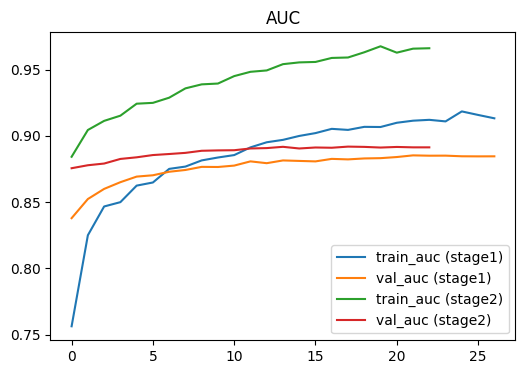

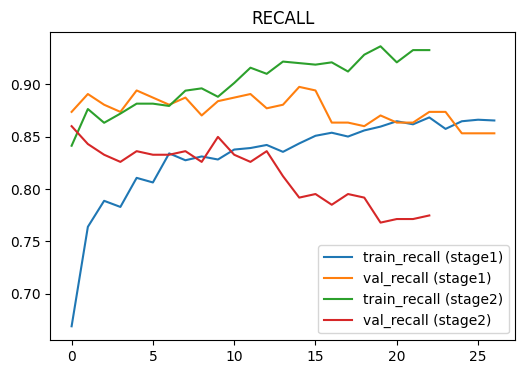

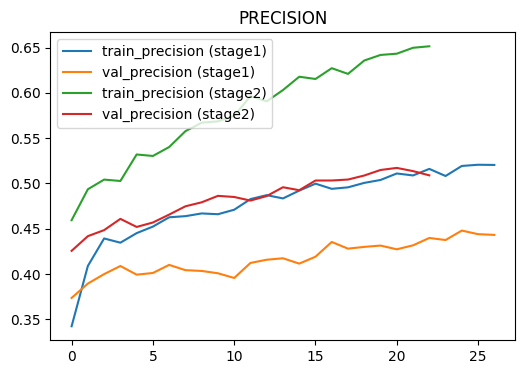

In [26]:
import matplotlib.pyplot as plt
def plot_metric(h1, h2, metric):
    plt.figure(figsize=(6,4))
    plt.plot(h1.history[metric], label=f"train_{metric} (stage1)")
    plt.plot(h1.history[f"val_{metric}"], label=f"val_{metric} (stage1)")
    plt.plot(h2.history[metric], label=f"train_{metric} (stage2)")
    plt.plot(h2.history[f"val_{metric}"], label=f"val_{metric} (stage2)")
    plt.legend()
    plt.title(metric.upper())
    plt.show()

plot_metric(history_stage1, history_stage2, "auc")
plot_metric(history_stage1, history_stage2, "recall")
plot_metric(history_stage1, history_stage2, "precision")


In [27]:
model.evaluate(test_ds)


47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 628ms/step - auc: 0.8795 - loss: 0.4498 - precision: 0.4762 - recall: 0.7676


[0.4310232102870941,
 0.8924011588096619,
 0.5066371560096741,
 0.7815699577331543]

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend((preds > 0.5).astype(int))

print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
print(confusion_matrix(y_true, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [29]:
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# Get y_true and y_prob from val_ds
y_true_val = np.concatenate([y.numpy() for _, y in val_ds]).astype(int).ravel()
y_prob_val = model.predict(val_ds).ravel()

fpr, tpr, thr = roc_curve(y_true_val, y_prob_val)

target_recall = 0.90
idx = np.where(tpr >= target_recall)[0][0]
best_thr = thr[idx]

print("Chosen threshold (val):", best_thr)
print("Val recall at threshold:", tpr[idx])


47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 458ms/step
Chosen threshold (val): 0.30874923
Val recall at threshold: 0.9010238907849829


In [30]:
y_true_test = np.concatenate([y.numpy() for _, y in test_ds]).astype(int).ravel()
y_prob_test = model.predict(test_ds).ravel()

y_pred_test = (y_prob_test >= best_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0

print("Test confusion matrix:", [[tn, fp],[fn, tp]])
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1: {f1:.4f}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 330ms/step
Test confusion matrix: [[np.int64(881), np.int64(329)], [np.int64(34), np.int64(259)]]
Accuracy: 0.7585
Precision: 0.4405
Recall: 0.8840
Specificity: 0.7281
F1: 0.5880


In [31]:
import pandas as pd

results = {
    "Model": "EfficientNet-B4",
    "AUC": np.max(tpr),
    "Recall": recall,
    "Precision": precision,
    "Specificity": specificity,
    "F1": f1,
    "Threshold": best_thr
}

pd.DataFrame([results]).to_csv("final_metrics_efficientnetB4.csv", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


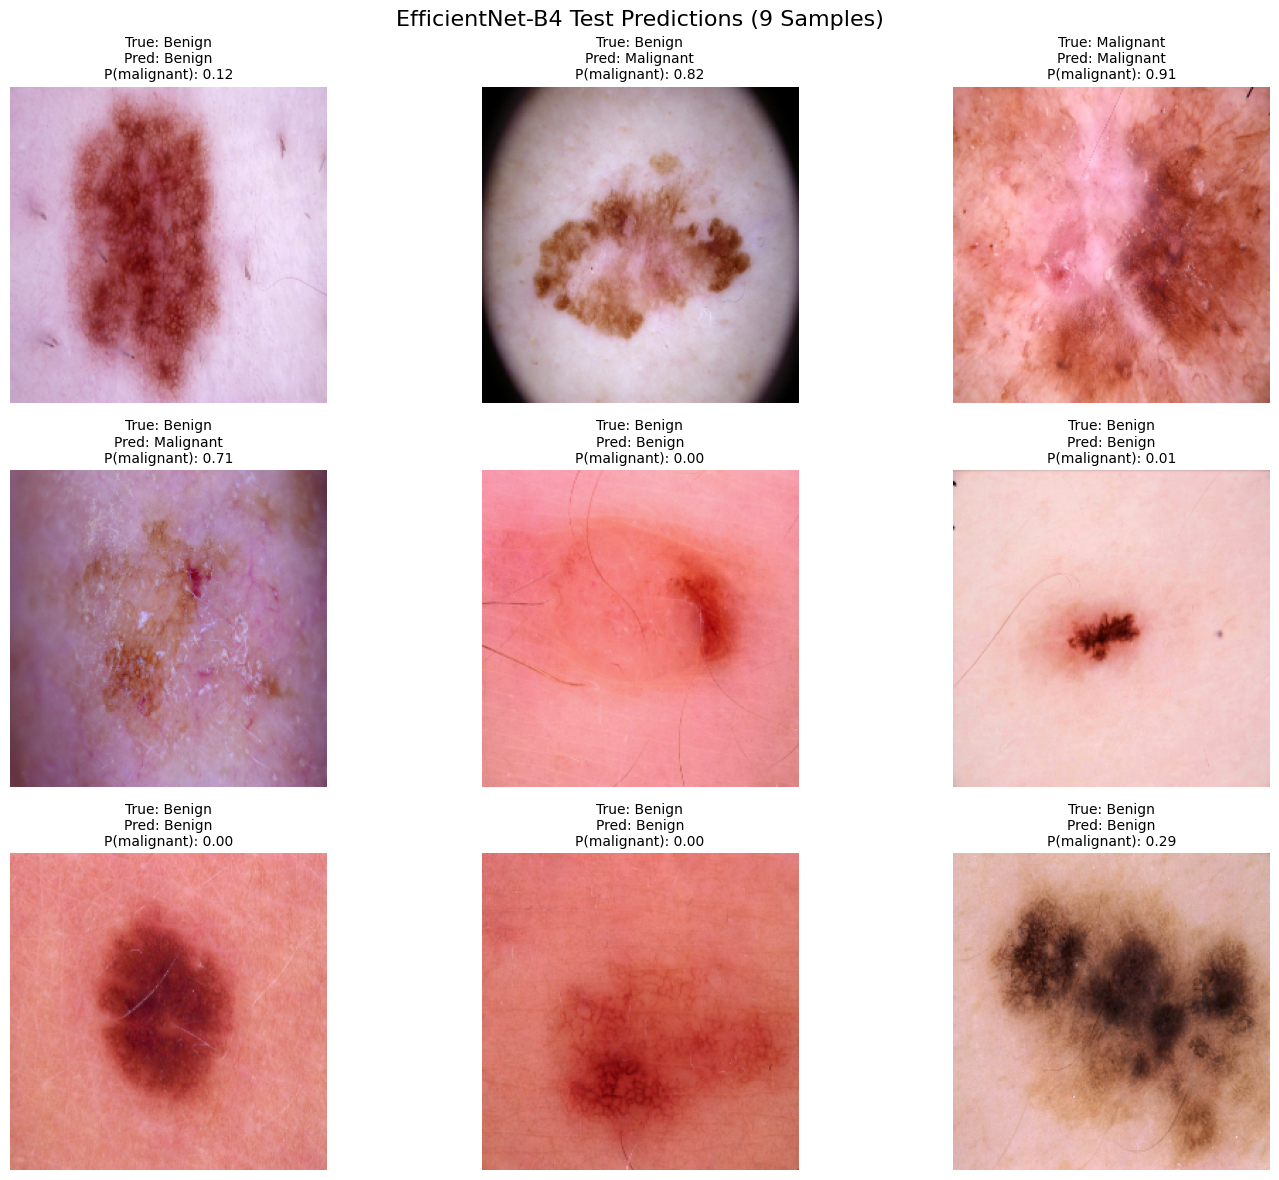

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# -------- SETTINGS --------
threshold = best_thr
num_images = 9

# Collect test images and labels
images_list = []
labels_list = []

for images, labels in test_ds.take(1):
    images_list = images.numpy()
    labels_list = labels.numpy()
    break

# Predict probabilities
probs = model.predict(images_list).ravel()

plt.figure(figsize=(15, 12))

for i in range(num_images):
    prob = probs[i]
    true_label = "Malignant" if labels_list[i] == 1 else "Benign"
    pred_label = "Malignant" if prob >= threshold else "Benign"

    # Reverse EfficientNet preprocessing for display
    img = images_list[i]
    img_display = (img - img.min()) / (img.max() - img.min())

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_display)
    plt.axis("off")

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"P(malignant): {prob:.2f}",
        fontsize=10
    )

plt.suptitle("EfficientNet-B4 Test Predictions (9 Samples)", fontsize=16)
plt.tight_layout()
plt.show()


In [33]:
model = tf.keras.models.load_model("best_model.keras")

In [34]:
model.evaluate(test_ds)

47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 309ms/step - auc: 0.8795 - loss: 0.4498 - precision: 0.4762 - recall: 0.7676


[0.4310232102870941,
 0.8924011588096619,
 0.5066371560096741,
 0.7815699577331543]

In [35]:
model.save("final_efficientnetB4_skin_cancer.keras")

In [36]:
from google.colab import files
files.download("final_efficientnetB4_skin_cancer.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>